# Save a BART model and predict in a fresh Python process

Choose the repository's notebook environment, then **Run All**. This walkthrough uses
synthetic data and `pymc-bart 0.13.1 / PyMC 6.3.2`. It trains once, saves the numerical
trace **and** tree histories, and verifies predictions after loading in a separate process.
The short chains demonstrate persistence; they are not a convergence assessment.

First-time setup from the repository root: `python -m pip install -r requirements-notebook.txt`.
Launch Jupyter from that same environment, as shown in the README. No manual kernel restart
is needed during the walkthrough.


## 1. Check the environment and choose a folder for saved files


In [1]:
import importlib.metadata as md
import json
import os
from pathlib import Path
import pickle
import subprocess
import sys

ROOT = Path.cwd()
assert (ROOT / "demo_current.py").exists(), "Open this notebook from the repository root."

# Verify the pinned numerical stack before importing PyMC into the kernel.
# Installation is done before opening Jupyter so Run All never changes a live kernel.
PACKAGES = ["pymc-bart", "pymc", "pytensor", "numpy", "bartrs"]
expected = {"pymc-bart": "0.13.1", "pymc": "6.3.2", "pytensor": "3.3.1",
            "numpy": "2.5.3", "bartrs": "0.4.0"}
installed = {name: md.version(name) for name in PACKAGES}
assert installed == expected, "Select the kernel installed from requirements-notebook.txt."

# Keep different PyTensor versions from sharing compiled extensions.
from runtime import configure_compiler_cache
configure_compiler_cache()

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from pymc_bart.utils import _get_posterior_sampler
from IPython.display import display

ARTIFACT_DIR = ROOT / "artifacts" / "notebook-demo"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_SEED = 281
print("Environment verified:", installed)
print("Files will be saved in artifacts/notebook-demo/.")


Environment verified: {'pymc-bart': '0.13.1', 'pymc': '6.3.2', 'pytensor': '3.3.1', 'numpy': '2.5.3', 'bartrs': '0.4.0'}
Files will be saved in artifacts/notebook-demo/.


## 2. Write the small model definition shared by training and prediction


In [2]:
%%writefile artifacts/notebook-demo/model_spec.py
"""The same model specification is used in two independent Python processes."""
import pymc as pm
import pymc_bart as pmb


def make_model(X, y):
    """Build a simple BART regression whose input row count can change.

    The noise scale is fixed to keep this example focused on tree persistence.
    Twenty trees are added together in each retained posterior ensemble.
    """
    with pm.Model() as model:
        x_data = pm.Data("X", X)
        mu = pmb.BART("mu", x_data, y, m=20)
        pm.Normal("y", mu=mu, sigma=0.15, observed=y, shape=x_data.shape[0])
    return model


Overwriting artifacts/notebook-demo/model_spec.py


## 3. Make a nonlinear dataset and a new grid of inputs to predict


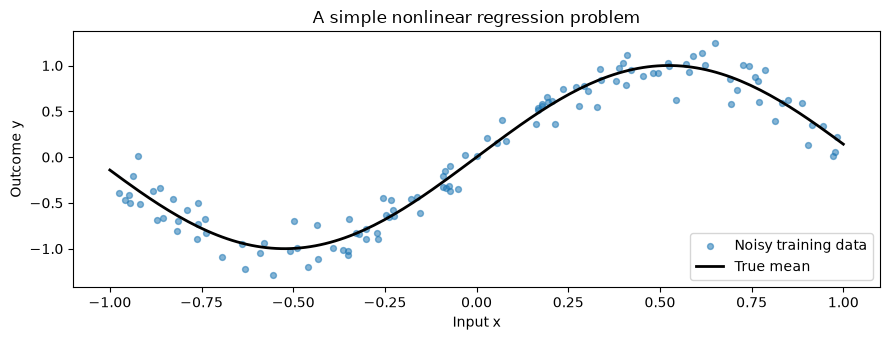

In [3]:
rng = np.random.default_rng(48)
X_train = rng.uniform(-1, 1, size=(120, 1))
y_train = np.sin(3 * X_train[:, 0]) + rng.normal(0, 0.15, size=120)
X_new = np.linspace(-1, 1, 151).reshape(-1, 1)
true_mean = np.sin(3 * X_new[:, 0])

# Files are the only data bridge to the later prediction process.
np.savez(ARTIFACT_DIR / "inputs.npz", X_train=X_train, y_train=y_train, X_new=X_new)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.scatter(X_train[:, 0], y_train, s=18, alpha=0.55, label="Noisy training data")
ax.plot(X_new[:, 0], true_mean, color="black", lw=2, label="True mean")
ax.set(xlabel="Input x", ylabel="Outcome y", title="A simple nonlinear regression problem")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


## 4. Train once and retain the posterior tree ensembles


In [4]:
# Import the model from the file above so the child process can use identical code.
if str(ARTIFACT_DIR) not in sys.path:
    sys.path.insert(0, str(ARTIFACT_DIR))
from model_spec import make_model

model = make_model(X_train, y_train)
with model:
    trace = pm.sample(
        draws=80, tune=100, chains=2, cores=2, random_seed=51,
        progressbar=False, compute_convergence_checks=False,
    )

# Use the same two-parallel-chain configuration verified by the repository tests.
sampler = _get_posterior_sampler(model["mu"].owner.op)
assert sampler.n_draws == 160
print(f"Retained {sampler.n_draws} ensembles, each containing 20 trees.")


Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Multiprocess sampling (2 chains in 2 jobs)


PGBART: [mu]


Sampling 2 chains for 100 tune and 80 draw iterations (200 + 160 draws total) took 1 seconds.


Retained 160 ensembles, each containing 20 trees.


## 5. Record predictions from the original trained model


In [5]:
with model:
    pm.set_data({"X": X_new})
    reference = pm.sample_posterior_predictive(
        trace,
        var_names=["mu", "y"],
        sample_vars=["mu", "y"],  # PyMC 6 must regenerate mu for the NEW inputs.
        predictions=True,
        backend="c",             # Avoids the tested default Numba shape issue.
        random_seed=PREDICTION_SEED,
        progressbar=False,
    )

reference_mu = reference.predictions["mu"].values.copy()
reference_y = reference.predictions["y"].values.copy()
# Check EVERY retained ensemble, not only the subset chosen by posterior prediction.
reference_all = sampler.sample_posterior(X_new, list(range(sampler.n_draws)), None)
np.savez_compressed(ARTIFACT_DIR / "reference.npz",
                    mu=reference_mu, y=reference_y, all_ensembles=reference_all)
print("Mean and outcome draws:", reference_mu.shape, reference_y.shape)


Sampling: [mu, y]


Mean and outcome draws: (2, 80, 151) (2, 80, 151)


## 6. Save the numerical trace and the tree histories as separate files


In [6]:
trace.to_netcdf(ARTIFACT_DIR / "trace.nc", engine="h5netcdf")

op = model["mu"].owner.op
# The plain list detaches the archive from BART's multiprocessing Manager proxy.
# In 0.13.1 these are per-chain histories, not one list entry per posterior draw.
archive = {"trees": list(op.all_trees), "n_outputs": op.n_outputs}
with (ARTIFACT_DIR / "trees.pkl").open("wb") as file:
    pickle.dump(archive, file, protocol=5)

metadata = {"versions": installed, "training_pid": os.getpid(),
            "retained_ensembles": sampler.n_draws, "prediction_seed": PREDICTION_SEED}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))

# Only load trusted pickle files: the format can execute code when unpickled.
display(pd.DataFrame([
    {"File": name, "Size (KiB)": round((ARTIFACT_DIR / name).stat().st_size / 1024, 1)}
    for name in ["trace.nc", "trees.pkl", "metadata.json", "inputs.npz", "reference.npz"]
]))


,File,Size (KiB)
0,trace.nc,185.6
1,trees.pkl,1791.4
2,metadata.json,0.2
3,inputs.npz,3.8
4,reference.npz,248.2


## 7. Release the trained objects before loading the saved model elsewhere


In [7]:
# The reference arrays remain only so this notebook can plot before/after results.
# The reload worker will have its own interpreter and read everything from files.
del model, trace, sampler, op, archive, reference
print("Trained objects released. The next process will not inherit this kernel's variables.")


Trained objects released. The next process will not inherit this kernel's variables.


## 8. Write the fresh-process loader that restores trees and predicts without training


In [8]:
%%writefile artifacts/notebook-demo/reload_worker.py
"""Read saved files and predict without using the training notebook's memory."""
import importlib.metadata as md
import json
import os
from pathlib import Path
import pickle
import sys

# The parent runs this script with cwd set to the repository root.
sys.path.insert(0, str(Path.cwd()))
from runtime import configure_compiler_cache
configure_compiler_cache()

import numpy as np
import pymc as pm
import xarray as xr
from pymc_bart.utils import _get_posterior_sampler, _posterior_sampler_cache
from checks import check_versions, compare_predictions
from model_spec import make_model


def predict(model, trace, X, seed):
    """Use the same data update and RNG seed as the pre-save reference."""
    with model:
        pm.set_data({"X": X})
        result = pm.sample_posterior_predictive(
            trace, var_names=["mu", "y"], sample_vars=["mu", "y"],
            predictions=True, backend="c", random_seed=seed, progressbar=False,
        )
    return {name: result.predictions[name].values for name in ["mu", "y"]}


def forbid_training(*args, **kwargs):
    """Make accidental retraining an explicit test failure."""
    raise AssertionError("This process is only allowed to LOAD and PREDICT.")


def main():
    """Demonstrate the NetCDF-only failure, then verify the restored tree state."""
    folder = Path(__file__).resolve().parent
    metadata = json.loads((folder / "metadata.json").read_text())
    current = {name: md.version(name) for name in metadata["versions"]}
    check_versions(metadata["versions"], current, list(current))
    assert os.getpid() != metadata["training_pid"]
    pm.sample = forbid_training

    inputs = np.load(folder / "inputs.npz")
    reference = np.load(folder / "reference.npz")
    trace = xr.open_datatree(folder / "trace.nc", engine="h5netcdf").load()
    model = make_model(inputs["X_train"], inputs["y_train"])
    op = model["mu"].owner.op
    assert len(op.all_trees) == 0, "A rebuilt model must start without trained trees."

    # Negative control: saving NetCDF alone does not restore BART for new data.
    try:
        bad = predict(model, trace, inputs["X_new"][:17], metadata["prediction_seed"])
    except (ValueError, TypeError) as error:
        trace_only = f"{type(error).__name__}: {str(error).splitlines()[0]}"
    else:
        expected = reference["mu"][:, :, :17]
        if bad["mu"].shape == expected.shape and np.allclose(bad["mu"], expected):
            raise AssertionError("The NetCDF-only negative control unexpectedly matched.")
        trace_only = "NetCDF-only predictions disagree with the trained model."

    # Positive case: restore the tree histories and their output dimension.
    with (folder / "trees.pkl").open("rb") as file:
        archive = pickle.load(file)
    op.all_trees[:] = archive["trees"]
    type(op).n_outputs = archive["n_outputs"]
    _posterior_sampler_cache.clear()

    sampler = _get_posterior_sampler(op)
    assert sampler.n_draws == metadata["retained_ensembles"]
    actual = predict(model, trace, inputs["X_new"], metadata["prediction_seed"])
    actual["all_ensembles"] = sampler.sample_posterior(
        inputs["X_new"], list(range(sampler.n_draws)), None,
    )
    errors = {name: compare_predictions(values, reference[name])
              for name, values in actual.items()}
    np.savez_compressed(folder / "reloaded_predictions.npz", **actual)
    report = {"passed": True, "training_pid": metadata["training_pid"],
              "reload_pid": os.getpid(), "trace_only_control": trace_only,
              "retained_ensembles": sampler.n_draws, "max_absolute_errors": errors}
    (folder / "reload_report.json").write_text(json.dumps(report, indent=2))
    print("Loaded the saved files and verified all predictions without retraining.")


# Required for safe model construction on platforms that spawn child processes.
if __name__ == "__main__":
    main()


Writing artifacts/notebook-demo/reload_worker.py


## 9. Run prediction in a separate Python process using only the saved files


In [9]:
completed = subprocess.run(
    [sys.executable, str(ARTIFACT_DIR / "reload_worker.py")],
    cwd=ROOT, capture_output=True, text=True, timeout=600,
)
if completed.returncode != 0:
    raise RuntimeError(completed.stdout + completed.stderr)
print(completed.stdout.strip())

report = json.loads((ARTIFACT_DIR / "reload_report.json").read_text())
assert report["passed"]
assert report["training_pid"] != report["reload_pid"]
print("Separate process confirmed:", report["training_pid"], "→", report["reload_pid"])
print("NetCDF alone:", report["trace_only_control"])
display(pd.DataFrame(report["max_absolute_errors"].items(),
                     columns=["Compared output", "Maximum absolute difference"]))


Loaded the saved files and verified all predictions without retraining.
Separate process confirmed: 74333 → 74357
NetCDF alone: ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (17,) and arg 1 with shape (120,).


,Compared output,Maximum absolute difference
0,mu,0.0
1,y,0.0
2,all_ensembles,0.0


## 10. Plot the restored predictions and confirm they match the original


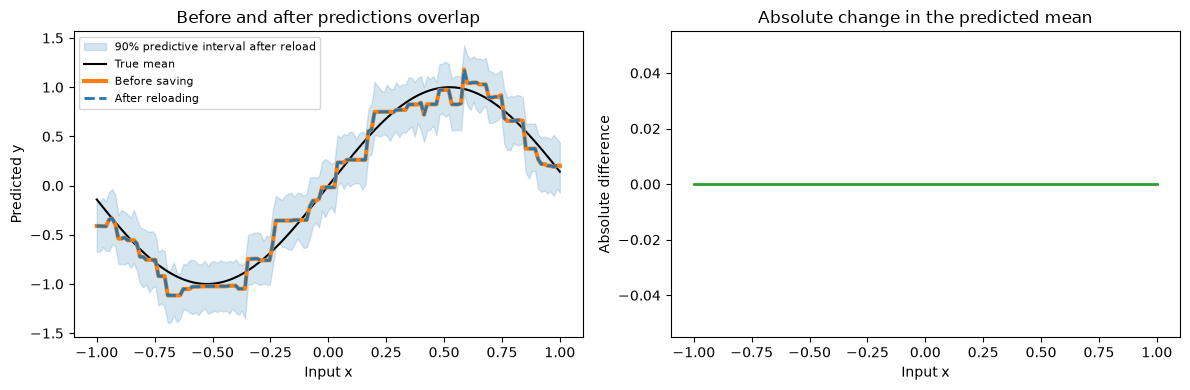

Verified 160 restored ensembles, latent means, and noisy outcomes.
No retraining occurred in the prediction process.


In [10]:
with np.load(ARTIFACT_DIR / "reloaded_predictions.npz") as reloaded:
    restored_mu = reloaded["mu"].copy()
    restored_y = reloaded["y"].copy()

before = reference_mu.mean(axis=(0, 1))
after = restored_mu.mean(axis=(0, 1))
# This band includes observation noise; it is wider than uncertainty in mu alone.
lower, upper = np.quantile(restored_y, [0.05, 0.95], axis=(0, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].fill_between(X_new[:, 0], lower, upper, alpha=0.18,
                     color="tab:blue", label="90% predictive interval after reload")
axes[0].plot(X_new[:, 0], true_mean, color="black", lw=1.5, label="True mean")
axes[0].plot(X_new[:, 0], before, lw=3, color="tab:orange", label="Before saving")
axes[0].plot(X_new[:, 0], after, "--", lw=2, color="tab:blue", label="After reloading")
axes[0].set(title="Before and after predictions overlap", xlabel="Input x", ylabel="Predicted y")
axes[0].legend(fontsize=8)
axes[1].plot(X_new[:, 0], np.abs(before - after), color="tab:green", lw=2)
axes[1].set(title="Absolute change in the predicted mean", xlabel="Input x", ylabel="Absolute difference")
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "prediction_comparison.png", dpi=140)
plt.show()

print(f"Verified {report['retained_ensembles']} restored ensembles, latent means, and noisy outcomes.")
print("No retraining occurred in the prediction process.")


## Done: the saved trace plus tree histories reproduce predictions without retraining

For deployment, keep the same model definition, feature preprocessing, and pinned package
versions with the saved files. This example verifies fresh-process loading on one environment;
it does not migrate tree archives between BART versions. The repository's other examples and
CI cover additional batch sizes, serializers, Python versions, and operating systems.
